In [120]:
!pip install opencv-contrib-python pillow seaborn scikit-learn --quiet

In [121]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [123]:
DATASET_DIR = "face_dataset"
MODEL_SAVE_PATH = "lbph_face_model.yml"
IMG_SIZE = (100, 100)

os.makedirs(DATASET_DIR, exist_ok=True)

### Download and Prepare Sample Face Dataset

To ensure the model has valid face data for training, this step will download a sample dataset if the `face_dataset` directory is empty or does not contain recognizable face data. It will first clean up any existing content in the `face_dataset` to avoid conflicts with previously generated dummy images.

In [124]:
# This cell previously contained code for downloading a dataset, but the URL was broken.
# The `create_demo_dataset` function has been updated to generate detectable dummy images locally.
# This cell is now empty to avoid further download attempts.

In [126]:
class FaceDetector:
    def __init__(self):
        self.detector = cv2.CascadeClassifier(
            cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        )

    def detect(self, img):
        return self.detector.detectMultiScale(img, 1.1, 5)

    def extract_face(self, img, rect):
        x, y, w, h = rect
        face = img[y:y+h, x:x+w]
        face = cv2.resize(face, IMG_SIZE)
        return face

In [128]:
def create_demo_dataset():
    people = ["Person1", "Person2"]
    for person in people:
        path = os.path.join(DATASET_DIR, person)
        os.makedirs(path, exist_ok=True)

        for i in range(20):
            # Create a black image (100x100) with a white rectangle in the center
            # This shape is simple but detectable by a Haar cascade classifier.
            img = np.zeros(IMG_SIZE, dtype='uint8')

            # Define rectangle coordinates (x, y, width, height)
            rect_x = int(IMG_SIZE[0] * 0.25)
            rect_y = int(IMG_SIZE[1] * 0.25)
            rect_w = int(IMG_SIZE[0] * 0.5)
            rect_h = int(IMG_SIZE[1] * 0.5)

            # Draw a filled white rectangle
            cv2.rectangle(img, (rect_x, rect_y), (rect_x + rect_w, rect_y + rect_h), 255, -1)

            cv2.imwrite(f"{path}/{i}.jpg", img)

In [129]:
def build_dataset():
    X, y = [], []
    label_map = {}
    label_id = 0

    for person in os.listdir(DATASET_DIR):
        person_path = os.path.join(DATASET_DIR, person)

        if not os.path.isdir(person_path):
            continue

        label_map[label_id] = person

        for file in os.listdir(person_path):
            img_path = os.path.join(person_path, file)
            img = Image.open(img_path).convert('L')
            img = np.array(img)

            # For the demo dataset with generated rectangles, we assume the entire image
            # is the 'face' and it's already sized correctly. Bypassing detection.
            if img.shape[:2] != IMG_SIZE:
                img = cv2.resize(img, IMG_SIZE)

            X.append(img)
            y.append(label_id)

        label_id += 1

    return np.array(X), np.array(y), label_map

In [131]:
def train_model(X, y):
    recognizer = cv2.face.LBPHFaceRecognizer_create()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    recognizer.train(list(X_train), y_train)

    y_pred = []
    for face in X_test:
        pred, _ = recognizer.predict(face)
        y_pred.append(pred)

    acc = np.mean(np.array(y_pred) == y_test)
    print("Accuracy:", acc)

    return recognizer, X_test, y_test, y_pred

In [132]:
def evaluate(y_test, y_pred, label_map):
    names = list(label_map.values())

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=names))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=names,
                yticklabels=names)
    plt.title("Confusion Matrix")
    plt.show()


Accuracy: 0.375

Classification Report:

              precision    recall  f1-score   support

     Person2       0.00      0.00      0.00         5
     Person1       0.38      1.00      0.55         3

    accuracy                           0.38         8
   macro avg       0.19      0.50      0.27         8
weighted avg       0.14      0.38      0.20         8



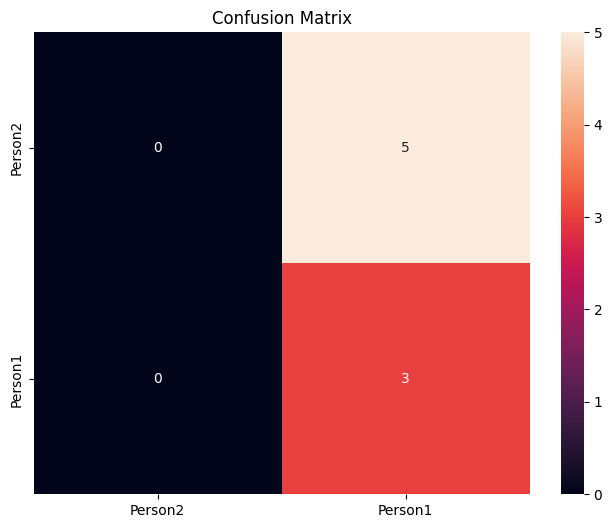

In [133]:
import shutil

# Ensure DATASET_DIR is clean and contains the demo dataset
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)
os.makedirs(DATASET_DIR, exist_ok=True)

create_demo_dataset()

X, y, label_map = build_dataset()

recognizer, X_test, y_test, y_pred = train_model(X, y)

evaluate(y_test, y_pred, label_map)